In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
img_path = "/content/drive/MyDrive/AI/Data/53929.jpg"
img = Image.open(img_path)
img_array = np.array(img)

print("Image shape:", img_array.shape)
print("Image mode:", img.mode)

Image shape: (1600, 2560, 3)
Image mode: RGB


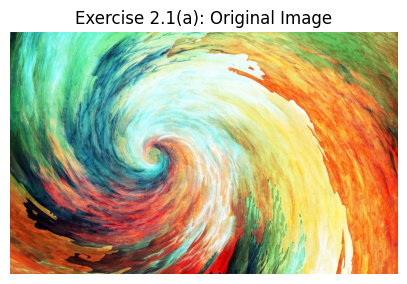

In [8]:
plt.figure(figsize=(5,5))
plt.imshow(img_array, cmap='gray')
plt.title("Exercise 2.1(a): Original Image")
plt.axis("off")
plt.show()

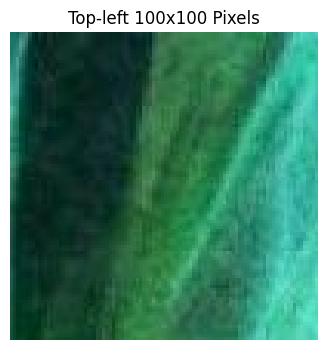

In [9]:
top_left = img_array[:100, :100]

plt.figure(figsize=(4,4))
plt.imshow(top_left, cmap='gray')
plt.title("Top-left 100x100 Pixels")
plt.axis("off")
plt.show()

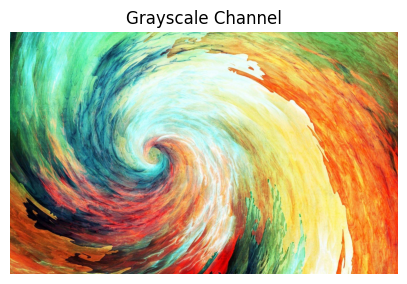

In [10]:
plt.figure(figsize=(5,5))
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Channel")
plt.axis("off")
plt.show()

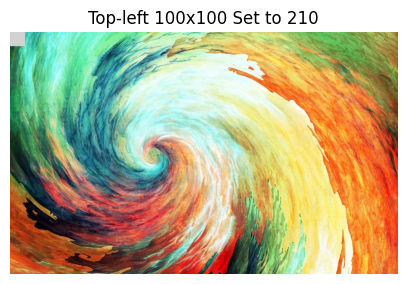

In [11]:
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.figure(figsize=(5,5))
plt.imshow(modified_img, cmap='gray')
plt.title("Top-left 100x100 Set to 210")
plt.axis("off")
plt.show()

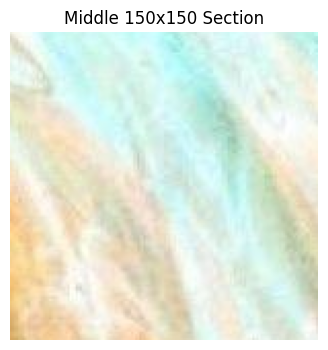

In [12]:
h, w, _ = img_array.shape
center_h, center_w = h // 2, w // 2
half = 75

middle_section = img_array[center_h-half:center_h+half, center_w-half:center_w+half]

plt.figure(figsize=(4,4))
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

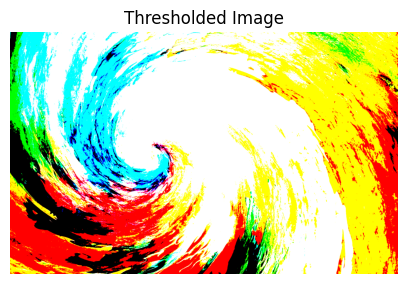

In [13]:
binary_img = np.where(img_array < 100, 0, 255).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(binary_img, cmap='gray')
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

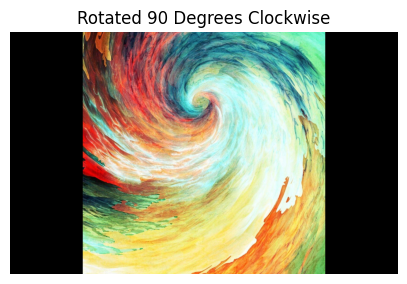

In [14]:
rotated_img = img.rotate(-90)

plt.figure(figsize=(5,5))
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

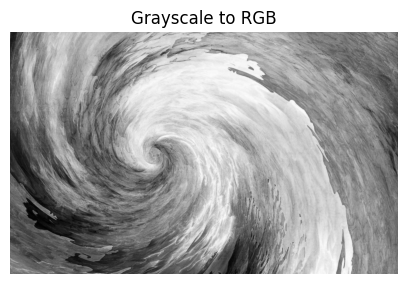

In [15]:

grayscale_2d = np.mean(img_array, axis=-1).astype(img_array.dtype)

rgb_img = np.stack([grayscale_2d, grayscale_2d, grayscale_2d], axis=-1)

plt.figure(figsize=(5,5))
plt.imshow(rgb_img)
plt.title("Grayscale to RGB")
plt.axis("off")
plt.show()

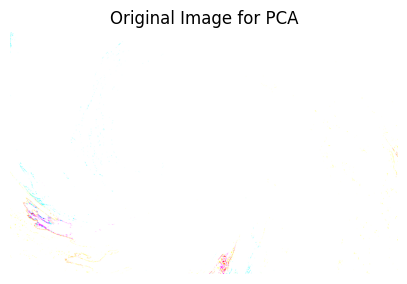

Matrix shape: (1600, 2560, 3)


In [16]:
X = img_array.astype(np.float64)

plt.figure(figsize=(5,5))
plt.imshow(X, cmap='gray')
plt.title("Original Image for PCA")
plt.axis("off")
plt.show()

print("Matrix shape:", X.shape)

In [17]:
mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector

print("Centered data shape:", X_centered.shape)

Centered data shape: (1600, 2560, 3)


In [18]:
h, w, c = X_centered.shape
X_centered_reshaped = X_centered.reshape(h, w * c)
cov_matrix = np.cov(X_centered_reshaped, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (7680, 7680)


In [19]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (7680,)
Eigenvectors shape: (7680, 7680)


In [20]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

print("Top 10 Eigenvalues:")
print(eigenvalues_sorted[:10])

Top 10 Eigenvalues:
[11889464.33085298  2424121.08780782  1215163.1500614   1091678.0103413
   700297.7320877    496290.42376761   467976.07542996   407305.21169099
   363526.18093227   301828.56946577]


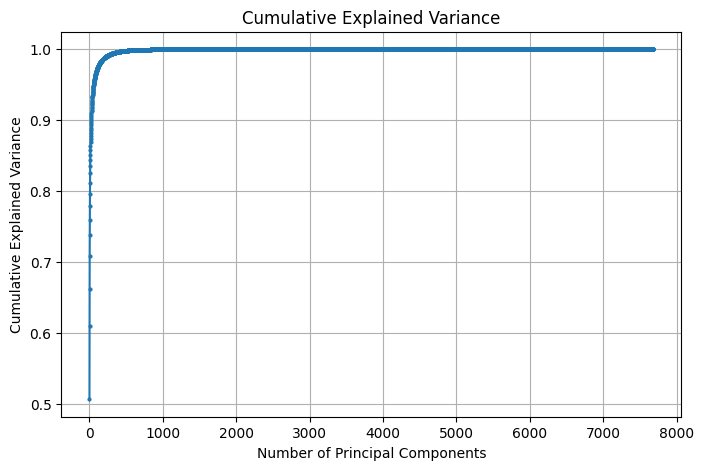

In [21]:
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8,5))
plt.plot(cumulative_explained_variance, marker='o', markersize=2)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [22]:
k_values = [10, 20, 50, 100]
print("Chosen principal components:", k_values)

Chosen principal components: [10, 20, 50, 100]


In [23]:
reconstructed_images = []

h, w, c = X.shape

for k in k_values:
    W = eigenvectors_sorted[:, :k]
    # Use X_centered_reshaped (h, w*c) for projection onto W (w*c, k)
    X_reduced = np.dot(X_centered_reshaped, W)
    # Reconstruct X_approx (h, w*c) from X_reduced (h, k) and W.T (k, w*c)
    X_approx = np.dot(X_reduced, W.T)

    # Reshape X_approx back to (h, w, c) to form an image
    X_approx_image = X_approx.reshape(h, w, c)

    # Add back the mean and clip values
    X_reconstructed = X_approx_image + mean_vector
    X_reconstructed = np.clip(X_reconstructed, 0, 255).astype(X.dtype)
    reconstructed_images.append(X_reconstructed)

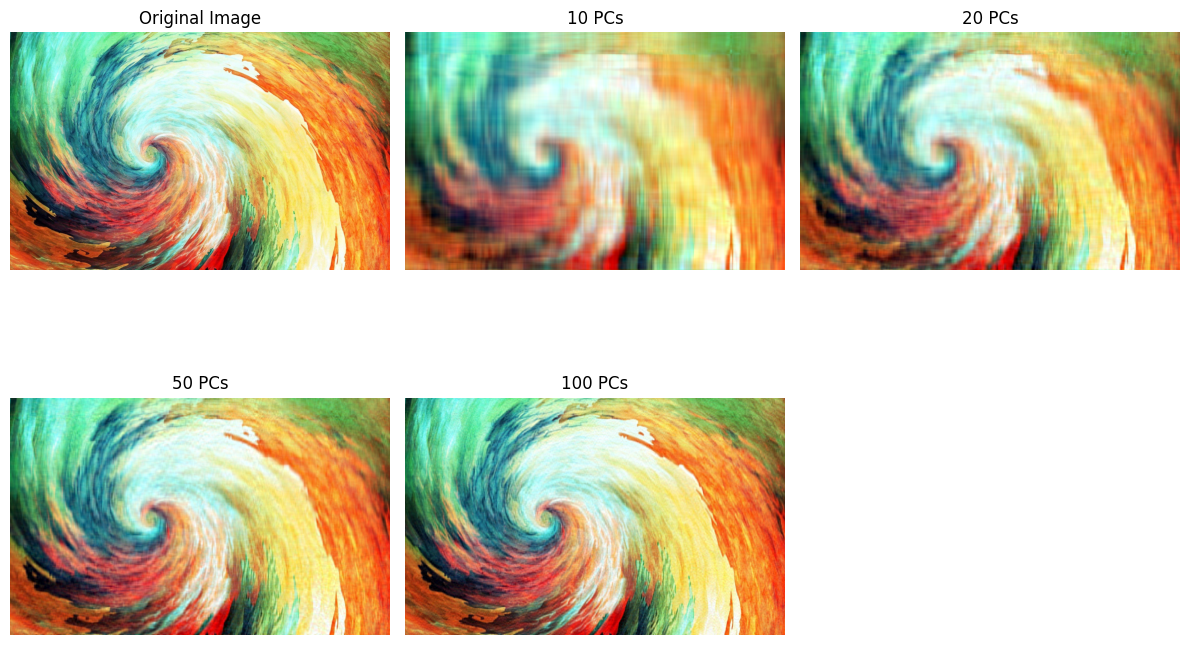

In [24]:
plt.figure(figsize=(12,8))

plt.subplot(2, 3, 1)
# Convert original image to uint8 for proper display without warnings
plt.imshow(X.astype(np.uint8), cmap='gray')
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(k_values):
    plt.subplot(2, 3, i + 2)
    # Convert reconstructed images to uint8 for proper display without warnings
    plt.imshow(reconstructed_images[i].astype(np.uint8), cmap='gray')
    plt.title(f"{k} PCs")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
for i, k in enumerate(k_values):
    mse = np.mean((X - reconstructed_images[i]) ** 2)
    retained_variance = cumulative_explained_variance[k - 1] * 100
    print(f"k = {k}")
    print(f"Retained Variance = {retained_variance:.2f}%")
    print(f"Mean Squared Error = {mse:.2f}")
    print()

k = 10
Retained Variance = 82.50%
Mean Squared Error = 532.86

k = 20
Retained Variance = 88.58%
Mean Squared Error = 347.29

k = 50
Retained Variance = 94.35%
Mean Squared Error = 171.97

k = 100
Retained Variance = 97.08%
Mean Squared Error = 88.85

